In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import datetime
import scipy.stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.dates as mdates


In [41]:
def decimal_year_to_date(decimal_year):
    year = int(decimal_year)
    rem = decimal_year - year
    base = datetime.datetime(year, 1, 1)
    result = base + datetime.timedelta(seconds=(base.replace(year=year+1) - base).total_seconds() * rem)
    return result.date()



In [43]:
tide = pd.read_excel("../old data/DataForLauren.xlsx").iloc[:,3:].dropna()
tide.columns= ["Year", "sealevel"]
tide['date'] = tide['Year'].apply(decimal_year_to_date)
tide.set_index(pd.DatetimeIndex(tide["date"]), inplace=True)
tide.drop("date",inplace=True,axis=1)
tide_roll = tide.rolling(15, center=True).mean()
tide

,Year,sealevel
date,,
2012-07-05,2012.51,10.34
2012-06-24,2012.48,13.75
2012-06-13,2012.45,17.11
2012-06-02,2012.42,16.48
2012-05-26,2012.40,18.96
...,...,...
1994-10-12,1994.78,-7.18
1994-10-01,1994.75,-10.42
1994-09-20,1994.72,-12.68


In [55]:
fred = pd.read_excel("../old data/DataForLauren.xlsx").iloc[:,0:2].dropna()
fred.columns=["Year", "RSL"]
fred['date'] = fred['Year'].apply(decimal_year_to_date)
fred.set_index("date", inplace=True)
fred.index = pd.DatetimeIndex(fred.index)
fred_roll = fred.rolling(5,center=True).mean()
fred_roll_ = fred.rolling(15,center=True).mean()
fred

,Year,RSL
date,,
2012-07-02,2012.500000,-42.797850
2012-05-02,2012.333333,-51.441175
2012-03-02,2012.166667,-80.918174
2012-01-01,2012.000000,-58.005210
2011-10-01,2011.750000,-73.171798
...,...,...
1995-05-02,1995.333333,-67.663202
1995-03-02,1995.166667,-73.167206
1995-01-01,1995.000000,-78.141195


In [19]:
data = pd.read_csv("CorrectedDataLatestApr82025.csv", header=None)
data.columns = ["date", "dc13"]
data

,date,dc13
0,2012.500000,-7.877600
1,2012.285714,-15.882800
2,2012.035714,-43.329200
3,2011.785714,-21.982000
4,2011.535714,-36.086400
...,...,...
253,1973.631579,-32.775288
254,1973.473684,-39.860677
255,1973.315789,-37.072684
256,1973.157895,-38.738476


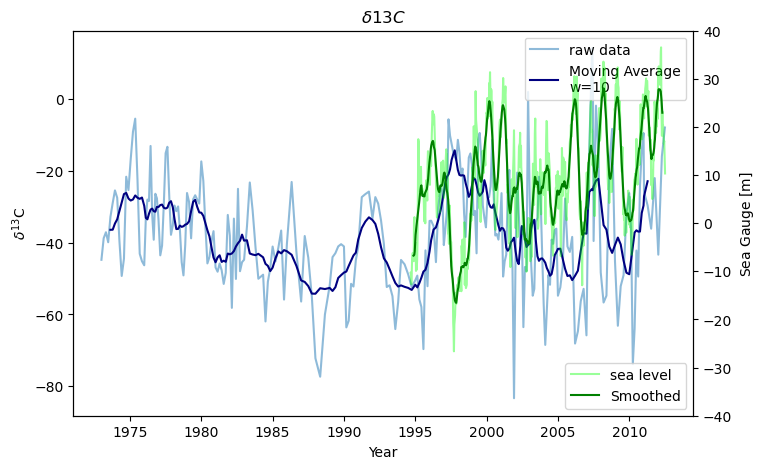

In [87]:
w = 10
data["roll"] = data["dc13"].rolling(w, center=True).mean()

fig, ax = plt.subplots(1, figsize=(8,5))

ax.plot(data["date"], data["dc13"], label="raw data", alpha=0.5)
ax.plot(data["date"], data["roll"], color="navy", label="Moving Average"+"\n"+"w={:}".format(w))
ax.legend()
ax.set_title(r"$\delta13C$")
#fig.savefig("d13C.pdf")


ax2 = ax.twinx()

ax2.plot(tide.iloc[:,0], tide.iloc[:,1], color="lime", alpha=0.4, label="sea level")
ax2.plot(tide_roll.iloc[:,0], tide_roll.iloc[:,1], color="green", label="Smoothed")
ax2.set_ylim(-40,40)
ax.set_ylabel(r'$\delta^{13} \text{C}$')
ax2.set_ylabel(r'$\text{Sea Gauge}$ [m]')
ax.set_xlabel("Year")
ax.legend(loc="upper right")
ax2.legend(loc="lower right")

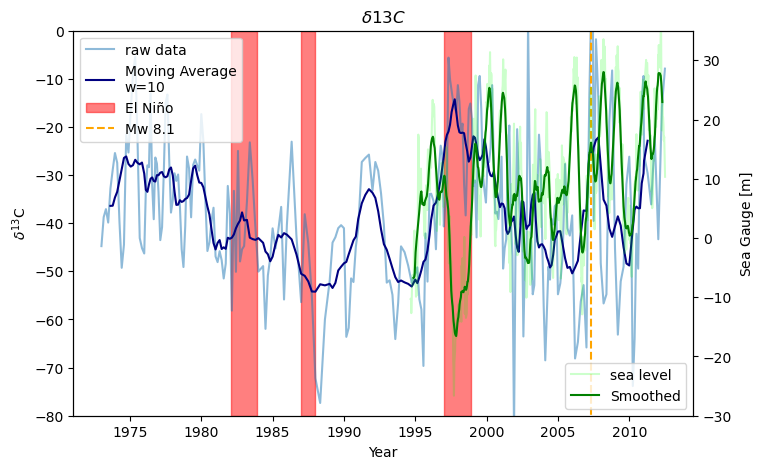

In [137]:
start = np.array([1982.1,1987, 1997])
end = np.array([1983.9, 1988, 1998.9])

w = 10
data["roll"] = data["dc13"].rolling(w, center=True).mean()

fig, ax = plt.subplots(1, figsize=(8,5))

ax.plot(data["date"], data["dc13"], label="raw data", alpha=0.5)
ax.plot(data["date"], data["roll"], color="navy", label="Moving Average"+"\n"+"w={:}".format(w))
ax.legend()
ax.set_title(r"$\delta13C$")
#fig.savefig("d13C.pdf")

for i in range(len(start)-1):
    ax.axvspan(start[i], end[i], alpha=0.5, color='red')
i=2
ax.axvspan(start[i], end[i], alpha=0.5, color='red', label="El Niño")

ax.vlines(2007.3,-100,80, color="orange", linestyles="--", label="Mw 8.1")

ax2 = ax.twinx()
ax.set_ylim(-80,0)
ax2.plot(tide.iloc[:,0], tide.iloc[:,1], color="lime", alpha=0.2, label="sea level")
ax2.plot(tide_roll.iloc[:,0], tide_roll.iloc[:,1], color="green", label="Smoothed")
ax2.set_ylim(-30,35)
ax.set_ylabel(r'$\delta^{13} \text{C}$')
ax2.set_ylabel(r'$\text{Sea Gauge}$ [m]')
ax.set_xlabel("Year")
ax.legend(loc="upper left")
ax2.legend(loc="lower right")

fig.savefig("new_data.png")

Text(0.5, 1.0, '$\\delta13C$')

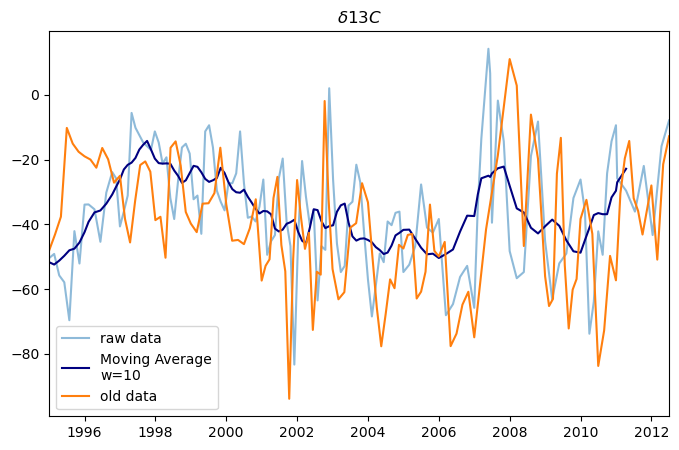

In [107]:
w = 10
data["roll"] = data["dc13"].rolling(w, center=True).mean()

fig, ax = plt.subplots(1, figsize=(8,5))

ax.plot(data["date"], data["dc13"], label="raw data", alpha=0.5)
ax.plot(data["date"], data["roll"], color="navy", label="Moving Average"+"\n"+"w={:}".format(w))

ax.plot(fred["Year"], fred["RSL"]+30, label="old data")

ax.set_xlim(1995,2012.5)
ax.legend()
ax.set_title(r"$\delta13C$")
#fig.savefig("d13C.pdf")

